git add makemore-master/
git commit -m "更新说明"
git push origin main

In [17]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [18]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [19]:
len(words)

32033

In [20]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [21]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [41]:
n_embd = 10
n_hidden = 200
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size,n_embd),generator = g)
W1 = torch.randn((n_embd*block_size,n_hidden),generator = g)
b1 = torch.randn(n_hidden,generator = g)
W2 = torch.randn((n_hidden,vocab_size),generator = g)
b2 = torch.randn(vocab_size,generator = g) 

parameters = [C,W1,b1,W2,b2]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

11897


In [42]:
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

    #minibatch construct
    ix = torch.randint(0,Xtr.shape[0],(batch_size,),generator = g)
    Xb,Yb = Xtr[ix],Ytr[ix]

    #forward pass
    emb = C[Xb]
    embcat = emb.view(emb.shape[0],-1)
    hpreact = embcat @ W1 + b1
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits,Yb)

    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    #update
    lr = 0.1 if i<100000 else 0.01  #学习率衰减（Step Learning Rate Decay）
    for p in parameters:
        p.data += -lr*p.grad

    #训练统计与日志跟踪（Track Stats）
    if i %10000 == 0:
        print(f'{i:7d}/{max_steps:7d}:{loss.item():.4f}')
    lossi.append(loss.log10().item())





      0/ 200000:27.8817
  10000/ 200000:2.8244
  20000/ 200000:2.5473
  30000/ 200000:2.8961
  40000/ 200000:2.0967
  50000/ 200000:2.5020
  60000/ 200000:2.4999
  70000/ 200000:2.0510
  80000/ 200000:2.4076
  90000/ 200000:2.3172
 100000/ 200000:2.0199
 110000/ 200000:2.3338
 120000/ 200000:1.8767
 130000/ 200000:2.3989
 140000/ 200000:2.2102
 150000/ 200000:2.1937
 160000/ 200000:2.0843
 170000/ 200000:1.8780
 180000/ 200000:1.9727
 190000/ 200000:1.8222


In [43]:
-torch.tensor(1/27).log()

tensor(3.2958)

![](images/2026-10-04-15-36-58.png)
![](images/2026-10-04-15-43-49.png)
![](images/2026-10-04-15-44-45.png)
![](images/2026-10-04-15-58-04.png)
![](images/2026-10-04-15-58-38.png)
![](images/2026-10-04-15-58-51.png)
![](images/2026-10-04-15-59-12.png)

![](images/2026-10-05-15-15-30.png)
![](images/2026-10-05-15-16-14.png)
![](images/2026-10-05-15-16-34.png)
![](images/2026-10-05-15-17-26.png)
![](images/2026-10-05-15-17-39.png)

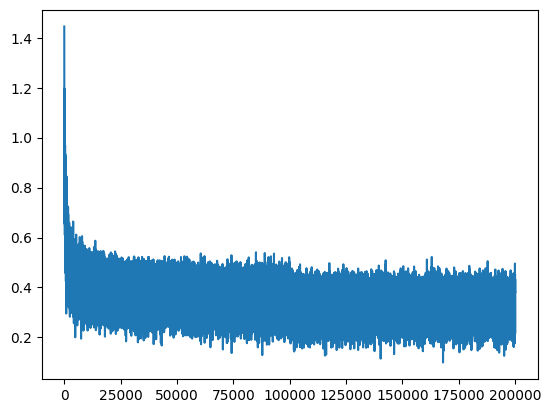

In [44]:
plt.plot(lossi) #等同于plt.plot(range(len(lossi)),lossi)

![](images/2026-10-04-16-10-00.png)

In [45]:
@torch.no_grad()
def split_loss(split):
    x,y = {
        'train':(Xtr,Ytr),
        'val':(Xdev,Ydev),
        'test':(Xte,Yte),
    }[split]
    emb = C[x]
    embcat = emb.view(emb.shape[0],-1)
    h = torch.tanh(embcat @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits,y)
    print(split,loss.item())

#评估模型在不同数据集（训练集、验证集、测试集）上的 Loss 表现   
split_loss('train')
split_loss('val')

train 2.12243390083313
val 2.1646578311920166


![](images/2026-10-04-16-48-05.png)
![](images/2026-10-04-17-07-15.png)
![](images/2026-10-04-17-07-33.png) 

In [46]:
#sample from the model
g = torch.Generator().manual_seed(2147483647+10)

for _ in range(20):
    out = []
    context = [0]*block_size
    while True:
        emb = C[torch.tensor([context])]    #(1,block_size,d)
        h = torch.tanh(emb.view(1,-1)@W1 +b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits,dim = 1)
        ix = torch.multinomial(probs,num_samples = 1,generator = g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break

    print(''.join(itos[i] for i in out))


mora.
mayah.
see.
mel.
rylee.
emmadiejd.
leg.
adelyn.
elin.
shi.
jen.
eden.
estanar.
kayziquetta.
noshir.
roshiriel.
kendreth.
konnie.
casube.
ged.


In [ ]:
n_embd = 10
n_hidden = 200
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size,n_embd),generator = g)
W1 = torch.randn((n_embd*block_size,n_hidden),generator = g)*(5/3)/((n_embd*block_size)**0.5)  #0.1
#b1 = torch.randn(n_hidden,generator = g)*0.01
W2 = torch.randn((n_hidden,vocab_size),generator = g)*0.01
b2 = torch.randn(vocab_size,generator = g) *0

bngain = torch.ones((1,n_hidden)) #批量归一化（batch normalization）的增益初始化为全1矩阵
bnbias = torch.zeros((1,n_hidden)) #批量归一化偏置项
bnmean_running = torch.zeros((1,n_hidden))
bnstd_running = torch.ones((1,n_hidden))

parameters = [C,W1,W2,b2,bngain,bnbias]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

11897


![](images/2026-10-05-15-47-45.png)
![](images/2026-10-05-15-57-33.png)
![](images/2026-10-05-15-58-29.png)

![](images/2026-10-08-22-39-44.png)

![](images/2026-10-08-23-33-16.png)
![](images/2026-10-08-23-33-42.png)
![](images/2026-10-08-23-34-10.png)
![](images/2026-10-08-23-34-19.png)
![](images/2026-10-08-23-35-18.png)
![](images/2026-10-08-23-35-35.png)
![](images/2026-10-08-23-36-52.png)

tensor(-0.0057) tensor(1.0153)
tensor(0.0015) tensor(1.0244)


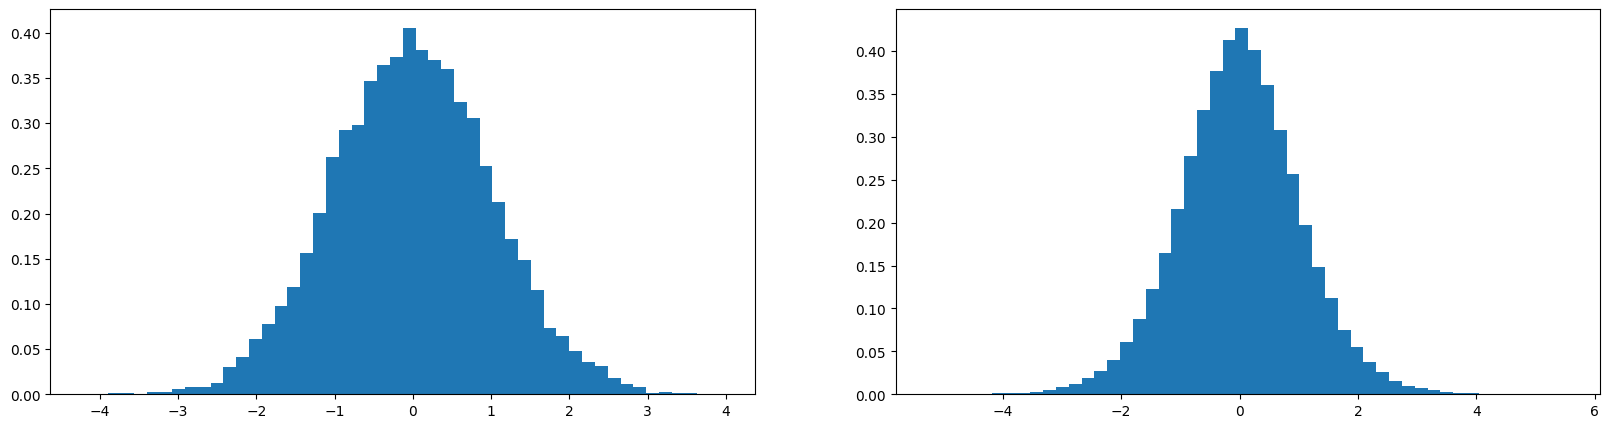

In [99]:
x = torch.randn(1000,10)
w = torch.randn(10,200)/10**0.5
y = x @ w
print(x.mean(),x.std())
print(y.mean(),y.std())
plt.figure(figsize = (20,5))
plt.subplot(121)
plt.hist(x.view(-1).tolist(),50,density = True);
plt.subplot(122)
plt.hist(y.view(-1).tolist(),50,density = True);

![](images/2026-10-07-16-22-23.png)
y未除10**0.5前的输出结果为：
tensor(-0.0003) tensor(1.0033)
tensor(0.0040) tensor(3.1974)
![](images/2026-10-07-17-24-06.png)
![](images/2026-10-07-17-25-00.png)
![](images/2026-10-07-17-25-18.png)
![](images/2026-10-07-17-33-56.png)
![](images/2026-10-07-17-27-08.png)
![](images/2026-10-07-17-27-33.png)
![](images/2026-10-07-17-28-13.png)
![](images/2026-10-07-17-29-04.png)
![](images/2026-10-07-17-29-16.png)

In [ ]:
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

    #minibatch construct
    ix = torch.randint(0,Xtr.shape[0],(batch_size,),generator = g)
    Xb,Yb = Xtr[ix],Ytr[ix]

    #forward pass
    emb = C[Xb]
    embcat = emb.view(emb.shape[0],-1)
    hpreact = embcat @ W1 #+ b1  #hidden layer pre-activation
    bnmeani = hpreact.mean(0,keepdim = True)
    bnstdi = hpreact.std(0,keepdim = True)
    hpreact = bngain * (hpreact - bnmeani)/bnstdi + bnbias

    with torch.no_grad():
        bnmean_running = 0.999*bnmean_running + 0.001*bnmeani
        bnstd_running = 0.999*bnstd_running + 0.001*bnstdi

    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits,Yb)

    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    #update
    lr = 0.1 if i<100000 else 0.01  #学习率衰减（Step Learning Rate Decay）
    for p in parameters:
        p.data += -lr*p.grad

    #训练统计与日志跟踪（Track Stats）
    if i %10000 == 0:
        print(f'{i:7d}/{max_steps:7d}:{loss.item():.4f}')
    lossi.append(loss.log10().item())

    #break



      0/ 200000:3.3147
  10000/ 200000:2.1942
  20000/ 200000:2.3443
  30000/ 200000:2.4160
  40000/ 200000:1.9913
  50000/ 200000:2.2978
  60000/ 200000:2.5254
  70000/ 200000:2.0707
  80000/ 200000:2.3107
  90000/ 200000:2.0663
 100000/ 200000:1.9933
 110000/ 200000:2.3179
 120000/ 200000:1.9123
 130000/ 200000:2.4505
 140000/ 200000:2.4321
 150000/ 200000:2.2003
 160000/ 200000:2.0463
 170000/ 200000:1.8839
 180000/ 200000:1.9983
 190000/ 200000:1.8873


![](images/2026-10-08-10-00-35.png)
![](images/2026-10-08-10-00-44.png)
![](images/2026-10-08-10-02-33.png)
![](images/2026-10-08-10-03-56.png)
![](images/2026-10-08-10-04-10.png)
![](images/2026-10-08-10-04-50.png)
![](images/2026-10-08-10-14-12.png)
![](images/2026-10-08-10-14-26.png)
![](images/2026-10-08-10-14-45.png)
![](images/2026-10-08-10-15-08.png)
![](images/2026-10-08-10-18-44.png)
![](images/2026-10-08-14-31-44.png)

```python
bngain = torch.ones((1,n_hidden)) 
bnbias = torch.zeros((1,n_hidden)) 
hpreact = bngain * (hpreact - hpreact.mean(0,keepdim = True))/hpreact.std(0,keepdim = True) +bnbias
```
![](images/2026-10-08-15-11-05.png)
![](images/2026-10-08-15-12-31.png)
![](images/2026-10-08-15-12-43.png)
![](images/2026-10-08-15-12-55.png)
![](images/2026-10-08-15-14-47.png)
![](images/2026-10-08-15-15-40.png)
![](images/2026-10-08-15-16-03.png)
![](images/2026-10-08-15-16-15.png)
![](images/2026-10-08-15-16-24.png)
![](images/2026-10-08-15-16-43.png)
![](images/2026-10-08-15-16-51.png)

本质上就是用滑动均值，代替了原本要在训练结束后‘跑一遍全量数据集’算出的全部样本均值！
![](images/2026-10-08-22-40-26.png)
![](images/2026-10-08-22-47-05.png)
![](images/2026-10-08-22-48-31.png)
![](images/2026-10-08-22-48-45.png)

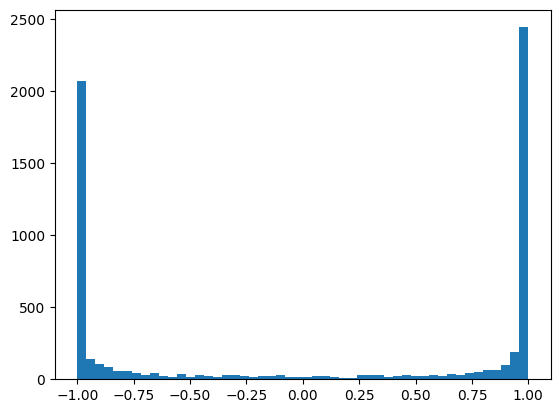

In [58]:
plt.hist(h.view(-1).tolist(),50);

![](images/2026-10-05-17-15-34.png)
![](images/2026-10-05-17-17-52.png)
![](images/2026-10-05-17-18-43.png)

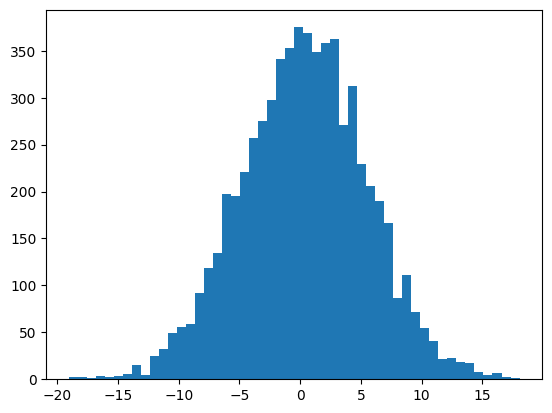

In [59]:
plt.hist(hpreact.view(-1).tolist(),50);

![](images/2026-10-05-15-47-16.png)

![](images/2026-10-07-09-59-21.png)
![](images/2026-10-07-09-59-32.png)
![](images/2026-10-07-11-34-13.png)
![](images/2026-10-07-11-34-37.png)
![](images/2026-10-07-11-30-22.png)
![](images/2026-10-07-11-30-36.png)

# 拓展激活函数
![](images/2026-10-07-14-51-26.png)
![](images/2026-10-07-14-53-02.png)
![](images/2026-10-07-14-53-22.png)
![](images/2026-10-07-14-54-10.png)
![](images/2026-10-07-14-54-22.png)

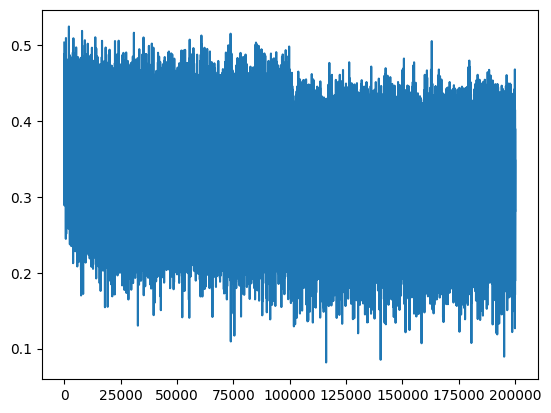

In [50]:
plt.plot(lossi)

In [ ]:
# with torch.no_grad():
#     emb = C[Xtr]
#     embcat = emb.view(emb.shape[0],-1)
#     hpreact = embcat @ W1 + b1
#     bnmean = hpreact.mean(0,keepdim = True)
#     bnstd = hpreact.std(0,keepkim = True)

为了让模型在后续“推理/测试（Evaluation/Inference）”阶段，只输入单个样本（例如用户发来的一句话）时，也能正常运行 BN 归一化
![](images/2026-10-08-15-48-01.png)
![](images/2026-10-08-16-24-26.png)
![](images/2026-10-08-16-24-39.png)
![](images/2026-10-08-16-25-19.png)
![](images/2026-10-08-16-53-36.png)

In [ ]:
@torch.no_grad()
def split_loss(split):
    x,y = {
        'train':(Xtr,Ytr),
        'val':(Xdev,Ydev),
        'test':(Xte,Yte),
    }[split]
    emb = C[x]
    embcat = emb.view(emb.shape[0],-1)
    hpreact = embcat @ W1 + b1
    #hpreact = bngain * (hpreact - hpreact.mean(0,keepdim = True))/hpreact.std(0,keepdim = True) + bnbias
    hpreact = bngain * (hpreact - bnmean_running)/bnstd_running + bnbias
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits,y)
    print(split,loss.item())

#评估模型在不同数据集（训练集、验证集、测试集）上的 Loss 表现   
split_loss('train')
split_loss('val')

train 2.0785984992980957
val 2.112783670425415


In [ ]:
class Linear:
    
    def __init__(self,fan_in,fan_out,bias = True):   #fan_in是输入特征的数量 fan_out是输出特征的数量
        self.weight = torch.randn((fan_in,fan_out),generator = g)/fan_in**0.5
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self,x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out

    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])


#class torch.nn.Linear(in_features, out_features, bias=True, device=None, dtype=None)
![](images/2026-10-09-10-31-18.png)
![](images/2026-10-09-10-32-12.png)
![](images/2026-10-09-10-34-49.png)
![](images/2026-10-09-10-35-30.png)
![](images/2026-10-09-10-37-03.png)
![](images/2026-10-09-10-40-37.png)
![](images/2026-10-09-10-41-17.png)
![](images/2026-10-09-10-41-34.png)

In [ ]:
class BatchNorm1d:
    def __init__(self,dim,eps = 1e-5,momentum = 0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        #parameters(trained with backprop)通过反向传播进行训练/更新
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        #buffers(trained with a running 'momentum update')
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self,x):
        #calculate the forward pass
        if self.training:
            xmean = x.mean(0,keepim = True) #batch mean
            xvar = x.var(0,keepdim = True) #batch variance
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x-xmean)/torch.sqrt(xvar+self.eps)
        self.out = self.gamma * xhat + self.beta
        #update the buffers
        if self.training:
            with torch.no_grad():
                self.running_mean = (1-self.momentum)*self.running_mean + self.momentum*xmean
                self.running_var = (1-self.momentum)*self.running_var + self.momentum*xvar
        return self.out

    def parameters(self):
        return [self.gamma,self.beta]

![](images/2026-10-09-14-56-31.png)
![](images/2026-10-09-11-31-38.png)
![](images/2026-10-09-11-34-37.png)
![](images/2026-10-09-11-35-21.png)
![](images/2026-10-09-14-54-12.png)
![](images/2026-10-09-14-53-33.png)
![](images/2026-10-09-14-41-25.png)
![](images/2026-10-09-14-42-31.png)

In [108]:
class Linear:
    
    def __init__(self,fan_in,fan_out,bias = True):   #fan_in是输入特征的数量 fan_out是输出特征的数量
        self.weight = torch.randn((fan_in,fan_out),generator = g)/fan_in**0.5
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self,x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out

    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])


class BatchNorm1d:
    def __init__(self,dim,eps = 1e-5,momentum = 0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        #parameters(trained with backprop)通过反向传播进行训练/更新
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        #buffers(trained with a running 'momentum update')
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self,x):
        #calculate the forward pass
        if self.training:
            xmean = x.mean(0,keepdim = True) #batch mean
            xvar = x.var(0,keepdim = True) #batch variance
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x-xmean)/torch.sqrt(xvar+self.eps)
        self.out = self.gamma * xhat + self.beta
        #update the buffers
        if self.training:
            with torch.no_grad():
                self.running_mean = (1-self.momentum)*self.running_mean + self.momentum*xmean
                self.running_var = (1-self.momentum)*self.running_var + self.momentum*xvar
        return self.out

    def parameters(self):
        return [self.gamma,self.beta]
    
class Tanh:
    def __call__(self,x):
        self.out = torch.tanh(x)
        return self.out
    def parameters(self):
        return []

n_embd = 10
n_hidden = 100
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size,n_embd),generator = g)
layers = [
    Linear(n_embd*block_size,n_hidden,bias = False),BatchNorm1d(n_hidden),Tanh(),
    Linear(n_hidden,n_hidden,bias = False),BatchNorm1d(n_hidden),Tanh(),
    Linear(n_hidden,n_hidden,bias = False),BatchNorm1d(n_hidden),Tanh(),
    Linear(n_hidden,n_hidden,bias = False),BatchNorm1d(n_hidden),Tanh(),
    Linear(n_hidden,n_hidden,bias = False),BatchNorm1d(n_hidden),Tanh(),
    Linear(n_hidden,vocab_size,bias = False),BatchNorm1d(vocab_size),
]

with torch.no_grad():
    # 1. 最后一层：削弱自信心（make less confident）
    #layers[-1].weight *= 0.1
    layers[-1].gamma *= 0.1
    # 2. 前面所有层：注入增益（apply gain）
    for layer in layers[:-1]:
        if isinstance(layer,Linear):
            layer.weight *= 5/3

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True


47024


![](images/2026-10-09-15-29-07.png)
![](images/2026-10-09-15-29-32.png)
![](images/2026-10-09-15-41-10.png)
![](images/2026-10-09-15-41-25.png)
![](images/2026-10-09-15-41-56.png)
![](images/2026-10-09-15-42-48.png)
![](images/2026-10-09-15-58-19.png)
![](images/2026-10-09-15-58-32.png)

#把BatchNorm1d插入到网络层结构
![](images/2026-10-09-22-29-53.png)
![](images/2026-10-09-22-43-26.png)
![](images/2026-10-09-22-43-42.png)
![](images/2026-10-09-22-38-39.png)
![](images/2026-10-09-22-46-18.png)
#为什么layers[-1].weight *= 0.1要改成layers[-1].gamma *= 0.1
![](images/2026-10-09-22-48-02.png)
![](images/2026-10-09-23-35-44.png)
![](images/2026-10-09-23-49-33.png)
![](images/2026-10-09-23-49-42.png)

In [109]:
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

     #minibatch construct
     ix = torch.randint(0,Xtr.shape[0],(batch_size,),generator = g)
     Xb,Yb = Xtr[ix],Ytr[ix] #batch X,Y

     #forward pass
     emb = C[Xb]
     x = emb.view(emb.shape[0],-1)
     for layer in layers:
          x = layer(x)
     loss = F.cross_entropy(x,Yb)

     #backward pass
     for p in parameters:
          p.grad = None
     loss.backward()

     #updata
     lr = 0.1 if i<100000 else 0.01
     for p in parameters:
          p.data += -lr*p.grad

     #统计与调试
     if i%10000 == 0:
          print(f'{i:7d}/{max_steps:7d}:{loss.item():.4f}')
     lossi.append(loss.log10().item())

     


      0/ 200000:3.2870
  10000/ 200000:2.3578
  20000/ 200000:2.1042
  30000/ 200000:1.9646
  40000/ 200000:2.2144
  50000/ 200000:2.2263
  60000/ 200000:1.7340
  70000/ 200000:2.1744
  80000/ 200000:2.1895
  90000/ 200000:1.8283
 100000/ 200000:2.3644
 110000/ 200000:2.2024
 120000/ 200000:2.1038
 130000/ 200000:1.8565
 140000/ 200000:1.8049
 150000/ 200000:1.9258
 160000/ 200000:1.8758
 170000/ 200000:1.8331
 180000/ 200000:2.2322
 190000/ 200000:2.0521


![](images/2026-10-09-16-42-53.png)
![](images/2026-10-09-16-49-17.png)
![](images/2026-10-09-16-49-31.png)
![](images/2026-10-09-16-52-12.png)